# k-Means Clustering
Clustering algorithms seek to learn, from the properties of the data, an optimal division or discrete labeling of groups of points.
Many clustering algorithms are available in Scikit-Learn and elsewhere, but perhaps the simplest to understand is an algorithm known as k means clustering, which is implemented in sklearn.cluster.KMeans .
We begin with the standard imports:


In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('seaborn-whitegrid')
import numpy as np

<ipython-input-8-cd9e54b682e8>:3: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


# Introducing k-Means
The k-means algorithm searches for a predetermined number of clusters within an unlabeled multidimensional dataset. It accomplishes this
using a simple conception of what the optimal clustering looks like:
The cluster center is the arithmetic mean of all the points belonging to the cluster.
Each point is closer to its own cluster center than to other cluster centers.
Those two assumptions are the basis of the k-means model.
First, let's generate a two-dimensional dataset containing four distinct blobs. To emphasize that this is an unsupervised algorithm, we will leave
the labels out of the visualization (see the following figure):

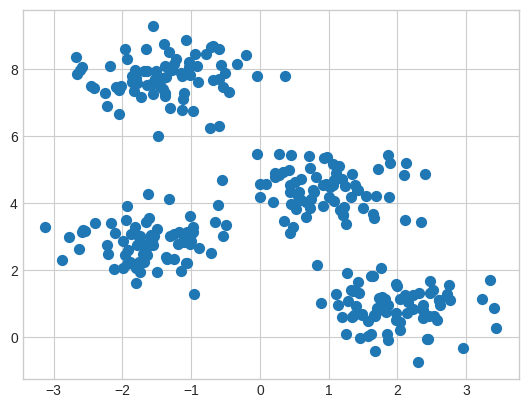

In [ ]:
from sklearn.datasets import make_blobs
X, y_true = make_blobs(n_samples=300, centers=4,
cluster_std=0.60, random_state=0)
plt.scatter(X[:, 0], X[:, 1], s=50);

By eye, it is relatively easy to pick out the four clusters. The k-means algorithm does this automatically, and in Scikit-Learn uses the typical
estimator API:

In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Let's visualize the results by plotting the data colored by these labels (the following figure). We will also plot the cluster centers as determined
by the k-means estimator:

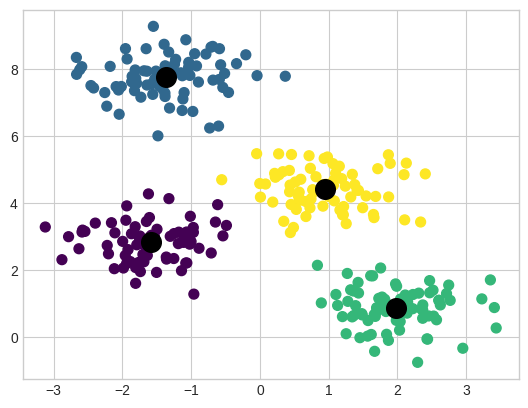

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200);

The good news is that the k-means algorithm (at least in this simple case) assigns the points to clusters very similarly to how we might assign
them by eye. But you might wonder how this algorithm finds these clusters so quickly: after all, the number of possible combinations of cluster
assignments is exponential in the number of data points—an exhaustive search would be very, very costly. Fortunately for us, such an
exhaustive search is not necessary: instead, the typical approach to k-means involves an intuitive iterative approach known as expectation–
maximization.

# Expectation–Maximization

Expectation–maximization (E–M) is a powerful algorithm that comes up in a variety of contexts within data science. k-means is a particularly
simple and easy-to-understand application of the algorithm, and we will walk through it briefly here. In short, the expectation–maximization
approach here consists of the following procedure:
1. Guess some cluster centers.
2. Repeat until converged:
1. E-step: Assign points to the nearest cluster center.
2. M-step: Set the cluster centers to the mean of their assigned points.

Here the E-step or expectation step is so named because it involves updating our expectation of which cluster each point belongs to. The M-
step or maximization step is so named because it involves maximizing some fitness function that defines the locations of the cluster centers—

in this case, that maximization is accomplished by taking a simple mean of the data in each cluster.

The literature about this algorithm is vast, but can be summarized as follows: under typical circumstances, each repetition of the E-step and M-
step will always result in a better estimate of the cluster characteristics.

# k-means is limited to linear cluster boundaries

The fundamental model assumptions of k-means (points will be closer to their own cluster center than to others) means that the algorithm will
often be ineffective if the clusters have complicated geometries.
In particular, the boundaries between k-means clusters will always be linear, which means that it will fail for more complicated boundaries.
Consider the following data, along with the cluster labels found by the typical k-means approach (see the following figure):

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


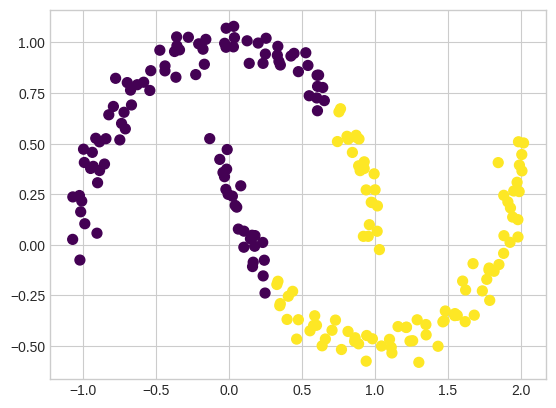

In [ ]:
from sklearn.datasets import make_moons
X, y = make_moons(200, noise=.05, random_state=0)
labels = KMeans(2, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels,
s=50, cmap='viridis');

# Kernelized k-means
Kernelized k-means is implemented in Scikit-Learn within the SpectralClustering estimator. It uses the graph of nearest neighbors to
compute a higher-dimensional representation of the data, and then assigns labels using a k-means algorithm (see the following figure):

/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_spectral_embedding.py:274: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


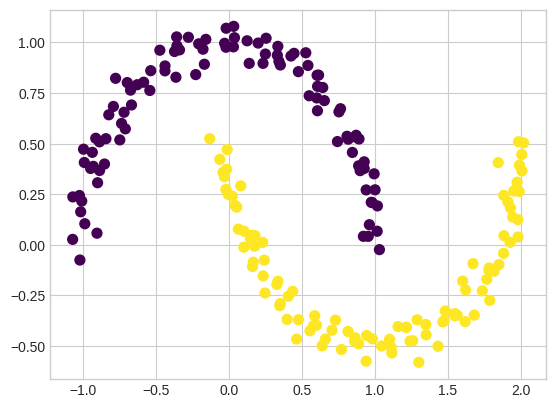

In [ ]:
from sklearn.cluster import SpectralClustering
model = SpectralClustering(n_clusters=2, affinity='nearest_neighbors',
assign_labels='kmeans')
labels = model.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels,
s=50, cmap='viridis');

We see that with this kernel transform approach, the kernelized k-means is able to find the more complicated nonlinear boundaries between
clusters.

**k-means can be slow for large numbers of samples**

Because each iteration of k-means must access every point in the dataset,
the algorithm can be relatively slow as the number of samples grows.
You might wonder if this requirement to use all data at each iteration can be relaxed; for example, you might just use a subset of the data to
update the cluster centers at each step.
This is the idea behind batch-based k-means algorithms, one form of which is implemented in sklearn.cluster.MiniBatchKMeans .

The interface for this is the same as for standard KMeans ; we will see an example of its use as we continue our discussion.

# Examples
Being careful about these limitations of the algorithm, we can use k-means to our advantage in a variety of situations. We'll now take a look at a
couple of examples.

# Example 1: k-Means on Digits
To start, let's take a look at applying k-means on the simple digits data.
Here we will attempt to use k-means to try to identify similar digits without using the original label information; this might be similar to a first
step in extracting meaning from a new dataset about which you don't have any a priori label information.
We will start by loading the dataset, then find the clusters.

In [ ]:
import pandas as pd
df = pd.read_csv("/content/Deepression.csv")
df.shape


(813, 16)

The clustering can be performed as we did before:

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer

df = pd.read_csv("/content/Deepression.csv")

# Identify non-numeric columns
non_numeric_cols = df.select_dtypes(exclude=['number']).columns

# Handle non-numeric columns (example: one-hot encoding)
df_encoded = pd.get_dummies(df, columns=non_numeric_cols)

# Impute missing values using SimpleImputer
imputer = SimpleImputer(strategy='mean') # Replace missing values with the mean
df_encoded_imputed = pd.DataFrame(imputer.fit_transform(df_encoded), columns=df_encoded.columns)

# Apply KMeans on the imputed DataFrame
kmeans_10 = KMeans(n_clusters=10, random_state=0)
clusters = kmeans_10.fit_predict(df_encoded_imputed) # Use the imputed DataFrame

kmeans_10.cluster_centers_.shape

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


(10, 25)

In [ ]:
df.head()

,Number,Sleep,Appetite,Interest,Fatigue,Worthlessness,Concentration,Agitation,Suicidal Ideation,Sleep Disturbance,Aggression,Panic Attacks,Hopelessness,Restlessness,Low Energy,Depression State
0,1,1.0,1.0,1.0,5.0,5.0,1.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,Mild
1,2,2.0,5.0,5.0,1.0,1.0,5.0,1.0,1.0,5.0,1.0,1.0,1.0,1.0,1.0,Moderate
2,3,5.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,Severe
3,4,1.0,1.0,1.0,5.0,5.0,1.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,No depression
4,5,2.0,5.0,5.0,1.0,1.0,5.0,1.0,1.0,5.0,1.0,1.0,1.0,1.0,1.0,Moderate


In [ ]:
# prompt: Using dataframe df: drop column Depression State

df = df.drop(columns=['Depression State'])


In [ ]:
df.head()

,Number,Sleep,Appetite,Interest,Fatigue,Worthlessness,Concentration,Agitation,Suicidal Ideation,Sleep Disturbance,Aggression,Panic Attacks,Hopelessness,Restlessness,Low Energy
0,1,1.0,1.0,1.0,5.0,5.0,1.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0
1,2,2.0,5.0,5.0,1.0,1.0,5.0,1.0,1.0,5.0,1.0,1.0,1.0,1.0,1.0
2,3,5.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
3,4,1.0,1.0,1.0,5.0,5.0,1.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0
4,5,2.0,5.0,5.0,1.0,1.0,5.0,1.0,1.0,5.0,1.0,1.0,1.0,1.0,1.0
